# 3. 高度なテクニカル指標

In [1]:
import os
import sys
from dotenv import load_dotenv
from pathlib import Path

import plotly.graph_objs as go
import talib as ta
import datetime as dt
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from mplfinance.original_flavor import candlestick_ohlc
import mplfinance as mpf
import matplotlib.dates as mdates
from backtesting import Backtest, Strategy
from Modules.rci import Rci

/workspace/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/workspace/.venv/lib/python3.12/site-packages/backtesting/_plotting.py:55: UserWarning: Jupyter Notebook detected. Setting Bokeh output to notebook. This may not work in Jupyter clients without JavaScript support, such as old IDEs. Reset with `backtesting.set_bokeh_output(notebook=False)`.
  warnings.warn('Jupyter Notebook detected. '


Loading BokehJS ...

## 3.1 RCI

In [2]:
sys.path.append("/workspace/notebook")
from Modules.get_market_data import GetMarketData
get_market_data = GetMarketData(Path('/workspace/data'))

### 3.1.3 RCIの表示

[*********************100%***********************]  1 of 1 completed


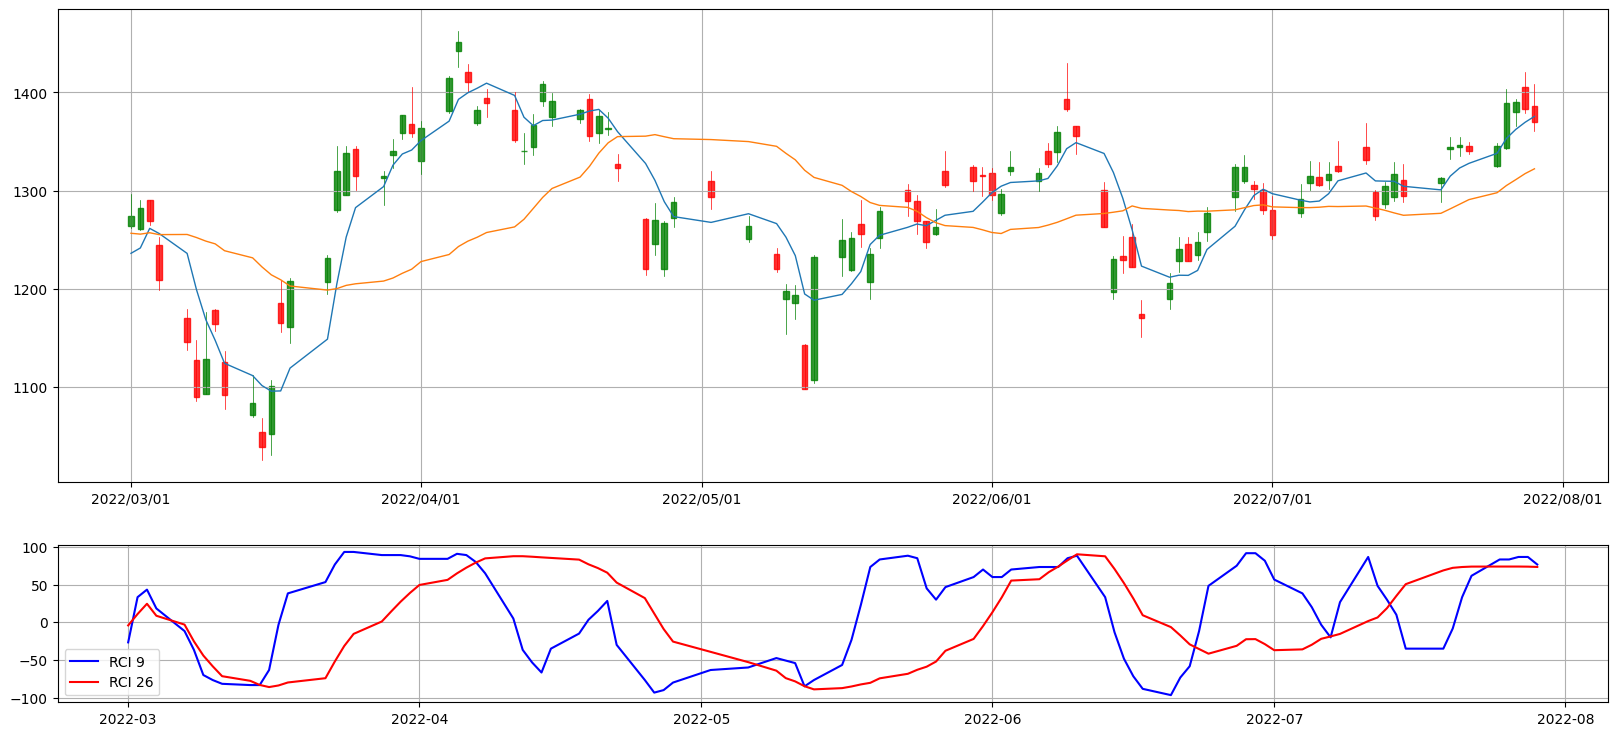

In [3]:
name = "SoftBank Group Corp."
code = "9984.T"

# チャート表示開始日
display_start_date = dt.datetime(2022, 1, 1)
# データ取得終了日(現在の日付を取得)
end_date = dt.datetime(2022, 7, 31)
# データ取得開始日
start_date = display_start_date - dt.timedelta(days=300)

### SoftBank Group Corp. (9984.T)
df = get_market_data.get_data_from_yfinance(code, start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'))
if isinstance(df.columns, pd.MultiIndex):
    df = df.droplevel(level=1, axis=1)

# データを取得する関数
df = df[df.index.weekday < 5]  # weekdayが0(月曜)〜4(金曜)のみを残す

close = df['Close']
df['ma5'] = ta.SMA(close ,timeperiod=5)
df['ma25'] = ta.SMA(close ,timeperiod=25)

rci = Rci()
df['RCI9'] = rci.RCI(close, timeperiod=9)
df['RCI26'] = rci.RCI(close, timeperiod=26)

# インデックスをDatetimeIndexに変換してから範囲でフィルタリング
df.index = pd.to_datetime(df.index)
df = df[(df.index >= dt.datetime(2022, 3, 1)) & (df.index <= dt.datetime(2022, 7, 31))]

# データを準備（matplotlib用）
df['Date'] = mdates.date2num(df.index)
ohlc_data = df[['Date', 'Open', 'High', 'Low', 'Close']]

# FigureとAxesを作成
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(20, 9), gridspec_kw={'height_ratios': [3, 1]})

# ローソク足チャートを描画
candlestick_ohlc(ax1, ohlc_data.values, width=0.6, colorup='g', colordown='r', alpha=0.8)

ax1.plot(df['Date'], df['ma5'], linewidth=1, label='ma5')

ax1.plot(df['Date'], df['ma25'], linewidth=1, label='ma25')

# RCIのプロット
ax2.plot(df.index, df['RCI9'], color='blue', label='RCI 9')
ax2.plot(df.index, df['RCI26'], color='red', label='RCI 26')
ax2.legend()

# X軸の日付フォーマットをyyyy/mm/ddに設定
ax1.xaxis_date()
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y/%m/%d'))

# 表示
ax1.grid()
ax2.legend()
ax2.grid()
plt.show()

## 3.2 パラボリック

[*********************100%***********************]  1 of 1 completed


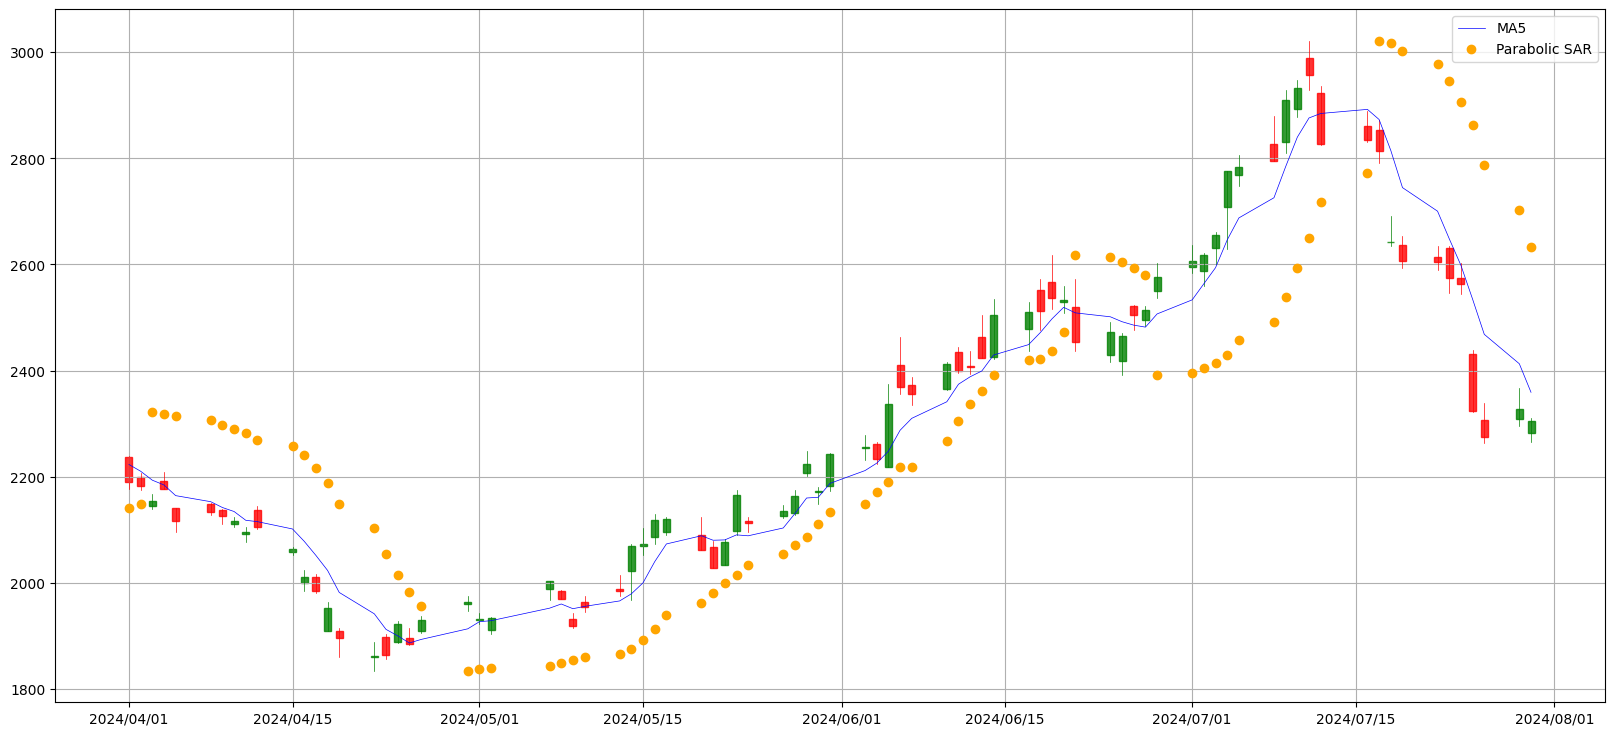

In [4]:
# 株価データを取得
name = "SoftBank Group Corp."
code = "9984.T"

# チャート表示開始日
display_start_date = dt.datetime(2024, 4, 1)
# データ取得終了日(現在の日付を取得)
end_date = dt.datetime(2024, 7, 31)
# データ取得開始日
start_date = display_start_date - dt.timedelta(days=300)

### SoftBank Group Corp. (9984.T)
df = get_market_data.get_data_from_yfinance(code, start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'))
if isinstance(df.columns, pd.MultiIndex):
    df = df.droplevel(level=1, axis=1)

# 移動平均線の計算
df['ma5'] = ta.SMA(df['Close'], timeperiod=5)
df['ma25'] = ta.SMA(df['Close'], timeperiod=25)

# パラボリックの計算
df['SAR'] = ta.SAR(df['High'], df['Low'], acceleration=0.02, maximum=0.2)

df = df[dt.datetime(2024,4,1):dt.datetime(2024,7,31)]

# ローソク足チャートを描くために、データフレームのインデックスをDatetimeIndexに変換
df.index = pd.to_datetime(df.index)


# データを準備（matplotlib用）
df['Date'] = mdates.date2num(df.index)
ohlc_data = df[['Date', 'Open', 'High', 'Low', 'Close']]

# FigureとAxesを作成
fig, ax = plt.subplots(figsize=(20, 9))

# ローソク足チャートを描画
candlestick_ohlc(ax, ohlc_data.values, width=0.6, colorup='g', colordown='r', alpha=0.8)

# 移動平均線のプロット
ax.plot(df['Date'], df['ma5'], linewidth=0.5, color='blue', label='MA5')
#ax.plot(df['Date'], df['ma25'], linewidth=0.5, color='green', label='MA25')

# Parabolic SARのプロット
ax.plot(df['Date'], df['SAR'], marker='o', linestyle='None', color='orange', label='Parabolic SAR')

# X軸の日付フォーマットをyyyy/mm/ddに設定
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y/%m/%d'))

# 凡例とグリッドを追加
ax.legend()
plt.grid()
plt.show()

In [5]:
rci.show_chart(code=code, name=name, start=display_start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'))

[*********************100%***********************]  1 of 1 completed


## 3.3 一目均衡表

In [6]:
from Modules.show_plot import ShowPlot
show_plot = ShowPlot()
show_plot.show_ichimoku(code=code, name=name, start=display_start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'))

[*********************100%***********************]  1 of 1 completed
